In [21]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Save model
import joblib

In [22]:
df = pd.read_csv("/content/heart.csv")

**4️⃣ Data Understanding**

In [23]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0

In [24]:
print(df['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


**5️⃣ Data Preprocessing**

In [25]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [26]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 723


In [27]:
print(df.shape)

(1025, 14)


**7️⃣ Define Features and Target**

In [28]:
X = df.drop("target", axis=1)
y = df["target"]

**8️⃣ Train-Test**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**9️⃣ Feature Scaling**

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**🔟 Algorithm Selection**

In [31]:
models = {

"Logistic Regression": LogisticRegression(),

"KNN": KNeighborsClassifier(),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(),

"SVM": SVC()

}

**1️⃣1️⃣ Model Training**

In [32]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

In [33]:
results_df = pd.DataFrame(
results,
columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.795122   0.756303  0.873786  0.810811
1                  KNN  0.834146   0.800000  0.893204  0.844037
2        Decision Tree  0.985366   1.000000  0.970874  0.985222
3        Random Forest  0.985366   1.000000  0.970874  0.985222
4                  SVM  0.887805   0.850877  0.941748  0.894009


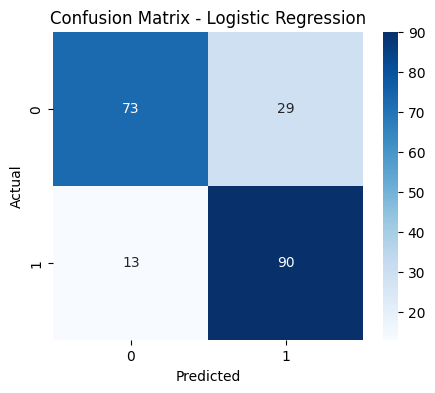

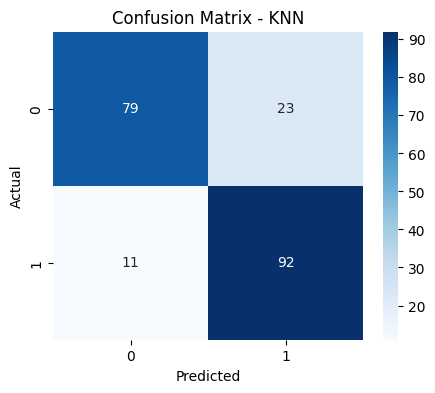

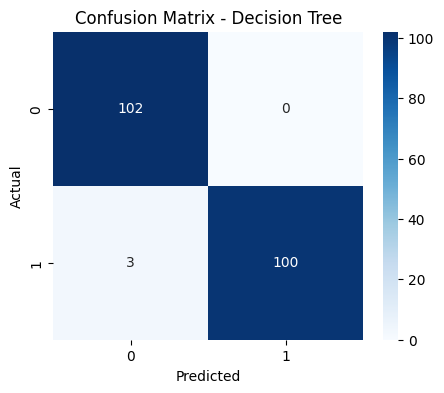

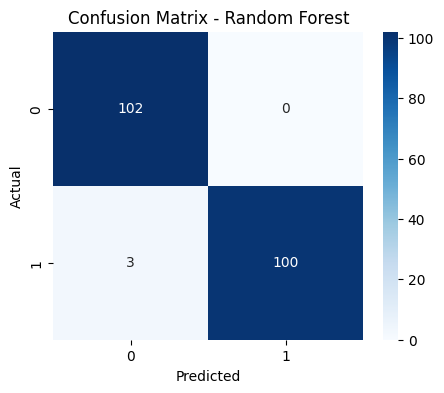

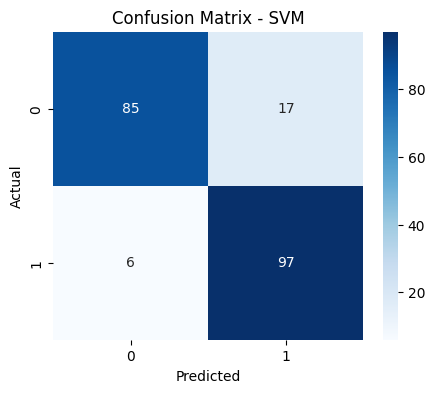

In [34]:
for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

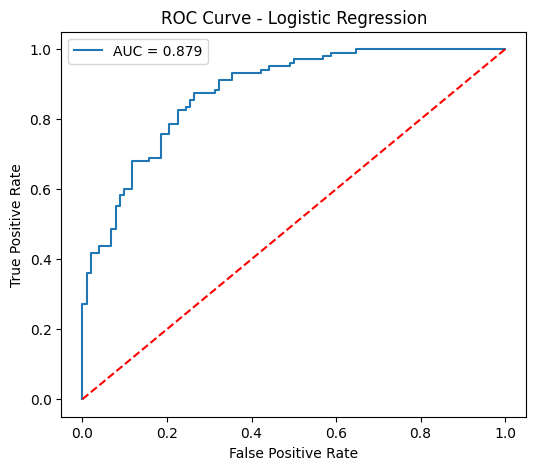

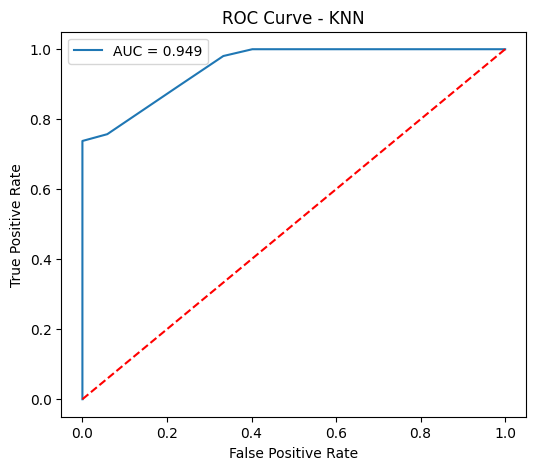

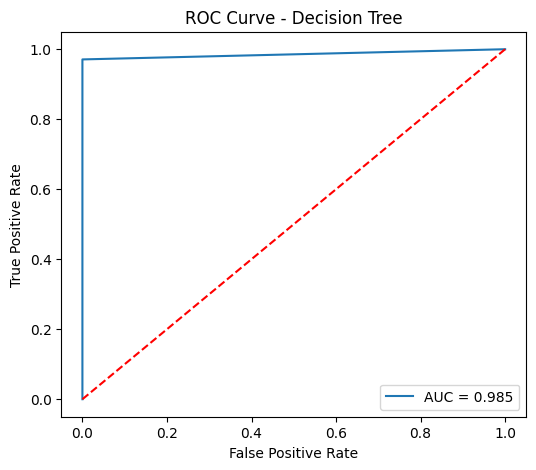

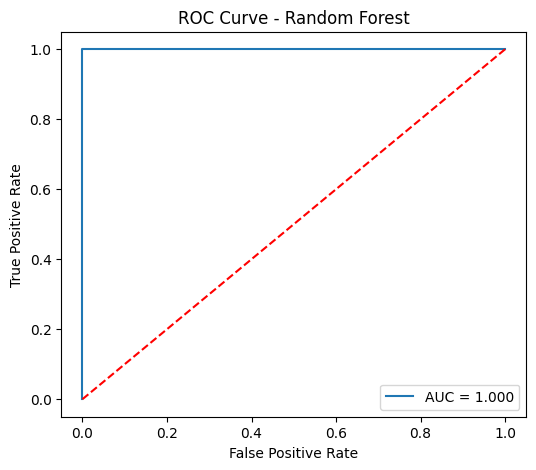

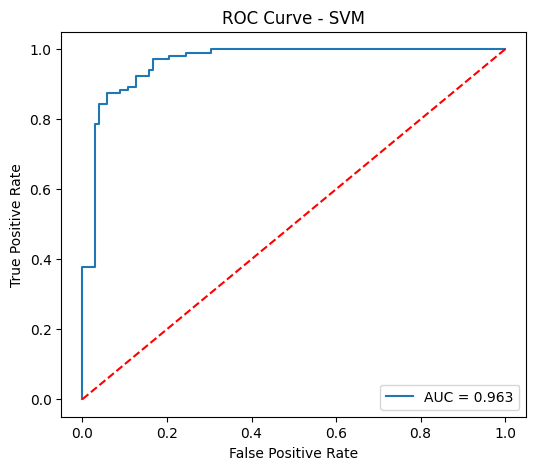

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # AUC score
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0,1],[0,1],'r--')

    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

In [39]:
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

RandomForestClassifier()

In [40]:
y_pred = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.9853658536585366


In [41]:
import joblib

joblib.dump(best_model, "heart_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully")

Model saved successfully
